# 함수의 극한

$x$가 $a$에 한없이 가까워질 때 $f(x)$가 $L$에 한없이 가까워지면

$$
\lim_{x \to a} f(x) = L
$$

이라고 한다. (이때 $f(a)$의 정의 여부는 극한과 직접 무관하다.)

## 1. 직관: 표로 다가가기

$f(x) = x^2$ 에서 $x \to 2$일 때

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
x = sp.symbols('x')

f_expr = x**2
a, L = 2, 4

# a에 왼쪽/오른쪽에서 다가가는 값
left = np.array([1.9, 1.99, 1.999, 1.9999])
right = np.array([2.1, 2.01, 2.001, 2.0001])

print("x → 2⁻")
for t in left:
    print(f"  x={t:.4f} → f(x)={t**2:.6f}")

print("x → 2⁺")
for t in right:
    print(f"  x={t:.4f} → f(x)={t**2:.6f}")

print(f"\n예상 극한 L = {L}")

x → 2⁻
  x=1.9000 → f(x)=3.610000
  x=1.9900 → f(x)=3.960100
  x=1.9990 → f(x)=3.996001
  x=1.9999 → f(x)=3.999600
x → 2⁺
  x=2.1000 → f(x)=4.410000
  x=2.0100 → f(x)=4.040100
  x=2.0010 → f(x)=4.004001
  x=2.0001 → f(x)=4.000400

예상 극한 L = 4


**np.array**: <br>
=> 수치로 다가가는 점들을 한 번에 다루기

**f(a) vs lim**: <br>
=> 극한은 $x=a$에서의 함숫값이 아니라 **근처**의 경향

## 2. 좌극한 · 우극한

$$
\lim_{x \to a^-} f(x) = L_-, \quad
\lim_{x \to a^+} f(x) = L_+
$$

$L_- = L_+$일 때만 $\displaystyle\lim_{x\to a} f(x)$가 존재한다.

In [2]:
# 조각함수: x < 0 이면 -1, x >= 0 이면 1
f_piece = sp.Piecewise((-1, x < 0), (1, True))

lim_left = sp.limit(f_piece, x, 0, dir='-')
lim_right = sp.limit(f_piece, x, 0, dir='+')
lim_both = sp.limit(f_piece, x, 0)

print("좌극한:")
display(lim_left)
print("우극한:")
display(lim_right)
print("양측 극한 (존재하면 값, 없으면 방향 표기):")
display(lim_both)
print(f"극한 존재?: {lim_left == lim_right}")

좌극한:


우극한:


양측 극한 (존재하면 값, 없으면 방향 표기):


극한 존재?: True


**sp.limit(expr, x, a, dir='-')**: <br>
=> 좌극한. `dir='+'`는 우극한

**sp.Piecewise**: <br>
=> 구간별로 다른 식 정의

## 3. sympy로 극한 계산

sin x / x


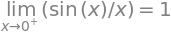

(x²-1)/(x-1)


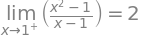

(√(x+1)-1)/x


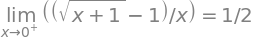

e^x as x→∞


In [3]:
examples = [
    (sp.sin(x) / x, 0, "sin x / x"),
    ((x**2 - 1) / (x - 1), 1, "(x²-1)/(x-1)"),
    ((sp.sqrt(x + 1) - 1) / x, 0, "(√(x+1)-1)/x"),
    (sp.exp(x), sp.oo, "e^x as x→∞"),
]

for expr, a, name in examples:
    result = sp.limit(expr, x, a)
    print("=" * 40)
    print(name)
    display(sp.Eq(sp.Limit(expr, x, a), result))

## 4. 발산 (무한대)

$$
\lim_{x \to 0^+} \frac{1}{x} = +\infty, \quad
\lim_{x \to 0^-} \frac{1}{x} = -\infty
$$

무한대로 발산해도 "극한이 존재한다"고 말하지 않는다 (실수 $L$이 아님).

In [4]:
expr = 1 / x
print("x → 0⁺:")
display(sp.limit(expr, x, 0, dir='+'))
print("x → 0⁻:")
display(sp.limit(expr, x, 0, dir='-'))
print("x → ∞:")
display(sp.limit(expr, x, sp.oo))
print("x → −∞:")
display(sp.limit(expr, x, -sp.oo))

x → 0⁺:


x → 0⁻:


x → ∞:


x → −∞:


## 5. 극한의 성질 (사칙연산)

$\lim f = A$, $\lim g = B$이면

$$
\lim(f\pm g)=A\pm B,\;
\lim(fg)=AB,\;
\lim\frac{f}{g}=\frac{A}{B}\ (B\neq 0)
$$

In [5]:
f = x**2
g = x + 1
a = 2

Lf = sp.limit(f, x, a)
Lg = sp.limit(g, x, a)

ops = {
    "f+g": f + g,
    "f-g": f - g,
    "f*g": f * g,
    "f/g": f / g,
}

for name, expr in ops.items():
    lim = sp.limit(expr, x, a)
    print(f"lim ({name}) at x={a} = {lim}")

print(f"\n검산: Lf={Lf}, Lg={Lg}")
print(f"  Lf+Lg={Lf+Lg}, Lf*Lg={Lf*Lg}, Lf/Lg={Lf/Lg}")

lim (f+g) at x=2 = 7
lim (f-g) at x=2 = 1
lim (f*g) at x=2 = 12
lim (f/g) at x=2 = 4/3

검산: Lf=4, Lg=3
  Lf+Lg=7, Lf*Lg=12, Lf/Lg=4/3


## 6. 그래프: 구멍과 접근

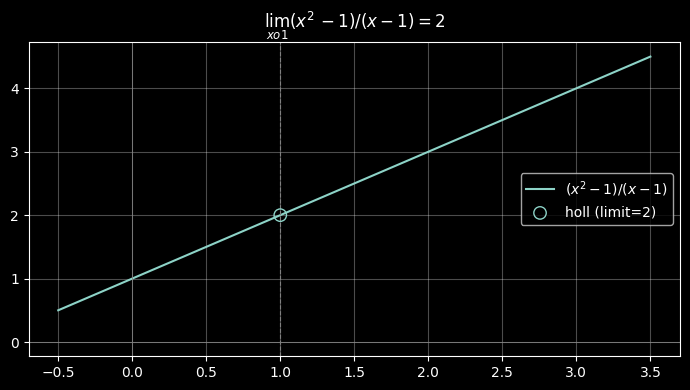

In [7]:
# (x²-1)/(x-1) = x+1 (x≠1) — x=1에서 구멍
xs = np.linspace(-0.5, 3.5, 400)
xs = xs[np.abs(xs - 1) > 0.02]
ys = (xs**2 - 1) / (xs - 1)

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label=r"$(x^2-1)/(x-1)$")
plt.scatter([1], [2], facecolors="none", edgecolors="C0", s=80, zorder=5, label="holl (limit=2)")
plt.axvline(1, color="gray", ls="--", lw=0.8)
plt.axhline(0, color="gray", lw=0.6)
plt.axvline(0, color="gray", lw=0.6)
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(r"$\lim_{x	o 1}(x^2-1)/(x-1)=2$")
plt.tight_layout()
plt.show()